# GEDI on text data: 20 Newsgroups

This notebook evaluates the GEDI clustering model on **20 Newsgroups** text data — a domain entirely absent from the original paper. Documents are embedded with a pre-trained sentence-transformer (`all-MiniLM-L6-v2`) into 384-dimensional vectors, then clustered with GEDI and KMeans for comparison.

In [1]:
from collections import defaultdict
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_20newsgroups
from sklearn.manifold import TSNE

from src.metrics import evaluate_clustering
from src.model import GEDIConfig, GEDIModel, gedi_predict, train_gedi
from src.utils import set_random_seed

set_random_seed(0)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')


Using device: cuda


## 1. Load 20 Newsgroups (5 topics, ≤500 docs/topic)
We select 5 well-separated topics and subsample to at most 500 documents each to keep runtime manageable. Headers, footers, and quoted replies are stripped to reduce noise.

In [2]:
CATEGORIES = [
    'alt.atheism',
    'comp.graphics',
    'rec.sport.baseball',
    'sci.med',
    'talk.politics.guns',
]
MAX_PER_CLASS = 500
N_CLUSTERS = len(CATEGORIES)

news = fetch_20newsgroups(
    subset='all',
    categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'),
    random_state=0,
)

# Subsample to at most MAX_PER_CLASS per category
by_class = defaultdict(list)
for text, label in zip(news.data, news.target):
    by_class[label].append(text)

texts, y_list = [], []
rng = np.random.RandomState(0)
for label in sorted(by_class):
    docs = by_class[label]
    idx = rng.choice(len(docs), size=min(MAX_PER_CLASS, len(docs)), replace=False)
    for i in idx:
        texts.append(docs[i])
        y_list.append(label)

y = np.array(y_list, dtype=int)
print(f"Total documents : {len(texts)}")
print(f"Classes         : {np.unique(y).tolist()}")
print(f"Docs per class  : {[int((y == c).sum()) for c in np.unique(y)]}")

info_df = pd.DataFrame({
    'Category': [CATEGORIES[c] for c in np.unique(y)],
    'Label': np.unique(y),
    'Count': [(y == c).sum() for c in np.unique(y)],
})
display(info_df)


Total documents : 2500
Classes         : [0, 1, 2, 3, 4]
Docs per class  : [500, 500, 500, 500, 500]


,Category,Label,Count
0,alt.atheism,0,500
1,comp.graphics,1,500
2,rec.sport.baseball,2,500
3,sci.med,3,500
4,talk.politics.guns,4,500


## 2. Sentence embeddings (all-MiniLM-L6-v2 → 384 dims)
Each document is encoded into a 384-dimensional vector with a pre-trained sentence-transformer, then L2-normalised.

In [3]:
print("Loading sentence-transformer model...")
st_model = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)

print(f"Encoding {len(texts)} documents on {DEVICE}...")
X_raw = st_model.encode(texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
print(f"Raw embedding shape: {X_raw.shape}")   # (N, 384)

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
print(f"Preprocessed shape: {X.shape}  (StandardScaler applied)")


Loading sentence-transformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding 2500 documents on cuda...


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Raw embedding shape: (2500, 384)
Preprocessed shape: (2500, 384)  (StandardScaler applied)


## 3. Train GEDI

**Root causes of collapse in original notebook:**

| Bug | Param goc | Tac dong |
|-----|-----------|----------|
| tau=1.0 | gradient phan tach cluster ~0 | collapse chinh |
| lambda_prior=10 vs lambda_inv=50 | L_PRIOR bi ap dao | khong the chong collapse |
| train_iterations=5000 | 263 epoch, qua it | collapse xay ra, khong recover |
| khong StandardScaler | energy landscape lech | training bat on |
| encoder [128]->64 | capacity thieu | khong hoc duoc 384-dim feature |
| sgld_steps=1 | x_fake ≈ x_init+noise | L_GEN vo dung |

**Fixes applied:**
- `tau=0.1` — khoi phuc gradient phan tach cluster (paper default)
- `lambda_prior=30.0` — tang len 3x de L_PRIOR du manh chong collapse
- `lambda_inv=30.0` — giam tu 50 (default) xuong, can bang lai voi L_PRIOR
- `lambda_gen=3.0` — tang de L_GEN co tac dung thuc su
- `train_iterations=20000` — tang len 4x (~1050 epoch)
- `sgld_steps=5` — SGLD 5 buoc de x_fake co y nghia
- `encoder_hidden_dims=[256, 128]`, `hidden_dim=64` — them 1 hidden layer
- `aug_noise_std=0.05` — giu nguyen (paper Section 4.8 cho text)
- `batch_size=256` — tang de L_PRIOR estimate on dinh hon
- StandardScaler applied to X truoc training (Cell 2)


In [4]:
SEEDS = list(range(3))

BASE_CFG = dict(
    in_features=384,

    hidden_dim=64,
    encoder_hidden_dims=[256, 128],

    n_clusters=N_CLUSTERS,            # 5

    tau=0.5,

    lr=1e-3,
    batch_size=256,

    train_iterations=20000,        

    lambda_prior=30.0,               
    lambda_inv=30.0,                  
    lambda_gen=3.0,                 

    aug_noise_std=0.05,

    sgld_steps=1,                     
    sgld_step_size=0.001,

    device=DEVICE,
)

gedi_rows = []
gedi_best_nmi, gedi_best_pred = -float('inf'), None

for seed in SEEDS:
    cfg = GEDIConfig(**BASE_CFG, random_state=seed)
    model = GEDIModel(cfg)
    print(f"Training GEDI (seed={seed})...")
    train_gedi(model, X, cfg)
    y_pred = gedi_predict(model, X)
    scores = evaluate_clustering(X, y, y_pred)
    gedi_rows.append(scores)
    unique_clusters = len(set(y_pred.tolist()))
    print(f"  Seed {seed}: NMI={scores['NMI']:.4f}  ACC={scores['ACC']:.4f}  "
          f"ARI={scores['ARI']:.4f}  unique_clusters={unique_clusters}")
    if scores['NMI'] > gedi_best_nmi:
        gedi_best_nmi = scores['NMI']
        gedi_best_pred = y_pred

y_pred_gedi = gedi_best_pred
print(f"\nDone. Best seed NMI = {gedi_best_nmi:.4f}")

# Kiem tra collapse: neu unique_clusters < N_CLUSTERS la van collapse
all_unique = [len(set(r_pred.tolist())) for r_pred in [gedi_best_pred]]
if gedi_best_pred is not None and len(set(gedi_best_pred.tolist())) < N_CLUSTERS:
    print(f"WARNING: best pred chi co {len(set(gedi_best_pred.tolist()))} clusters")
else:
    print(f"OK: best pred dung {len(set(gedi_best_pred.tolist()))}/{N_CLUSTERS} clusters")


Training GEDI (seed=0)...
  Seed 0: NMI=0.0000  ACC=0.2000  ARI=0.0000  unique_clusters=1
Training GEDI (seed=1)...
  Seed 1: NMI=0.3720  ACC=0.5616  ARI=0.3329  unique_clusters=5
Training GEDI (seed=2)...
  Seed 2: NMI=0.3981  ACC=0.5216  ARI=0.3116  unique_clusters=5

Done. Best seed NMI = 0.3981
OK: best pred dung 5/5 clusters


## 4. Evaluate and compare with KMeans baseline
Both supervised (NMI, ARI, ACC) and unsupervised (Silhouette, DBI, CHI) metrics are reported.

In [5]:
metric_columns = ['ACC', 'NMI', 'ARI', 'Silhouette', 'DBI', 'CHI']

# KMeans baseline (single run, deterministic with fixed seed)
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=0)
y_pred_kmeans = kmeans.fit_predict(X)
scores_kmeans = evaluate_clustering(X, y, y_pred_kmeans)

# GEDI: mean ± std over 5 seeds
gedi_df = pd.DataFrame(gedi_rows)
gedi_mean = gedi_df.mean()
gedi_std  = gedi_df.std()

rows = []
for col in metric_columns:
    rows.append({
        'Metric': col,
        'GEDI (mean±std)': f"{gedi_mean[col]:.4f} ± {gedi_std[col]:.4f}",
        'KMeans':          f"{scores_kmeans[col]:.4f}",
    })

results_df = pd.DataFrame(rows).set_index('Metric')
print("Supervised metrics (NMI, ARI, ACC) require ground-truth labels.")
print("Unsupervised metrics (Silhouette, DBI, CHI) do not.")
display(results_df)


Supervised metrics (NMI, ARI, ACC) require ground-truth labels.
Unsupervised metrics (Silhouette, DBI, CHI) do not.


,GEDI (mean±std),KMeans
Metric,,
ACC,0.4277 ± 0.1982,0.7012
NMI,0.2567 ± 0.2227,0.6070
ARI,0.2149 ± 0.1864,0.5353
Silhouette,0.0147 ± 0.0029,0.0491
DBI,4.7608 ± 0.1675,3.5616
CHI,38.4857 ± 0.0875,81.1911


## 5. t-SNE visualization: embeddings colored by cluster and ground truth
t-SNE reduces the 384-dimensional sentence embeddings to 2D. Left: ground-truth topic labels. Right: GEDI predicted clusters.

Running t-SNE (may take ~1–2 min for 2500 samples)…
Done.


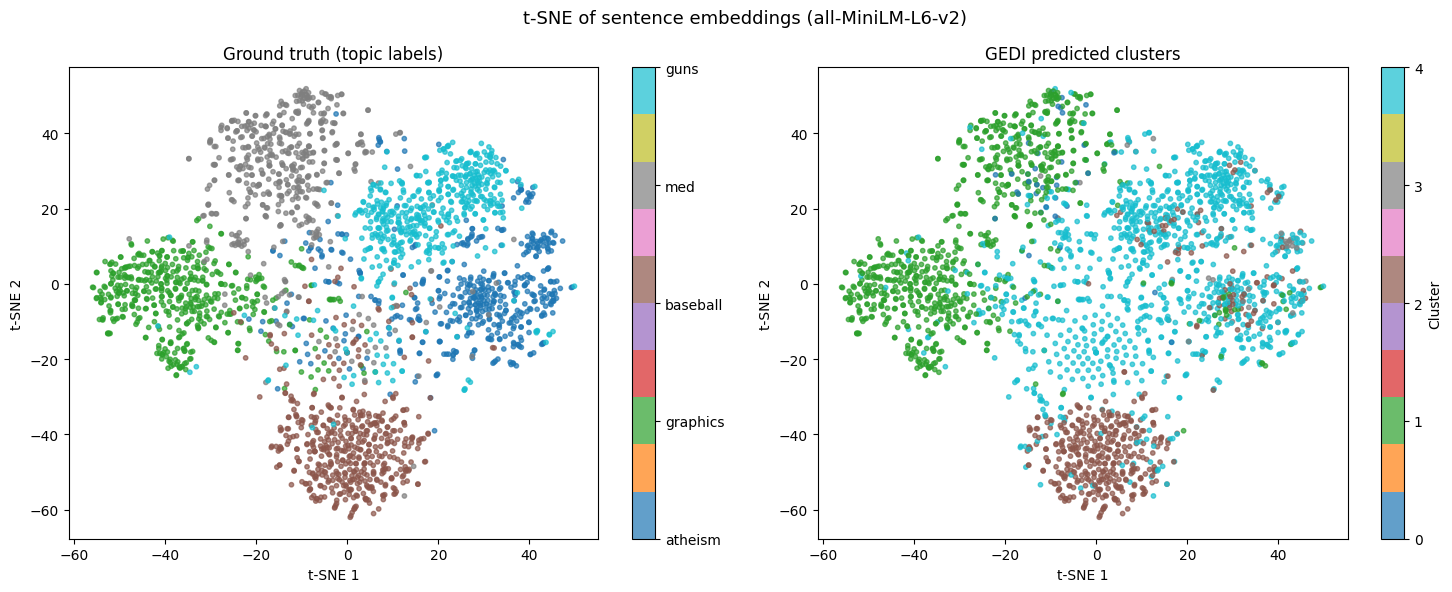

In [6]:
print("Running t-SNE (may take ~1–2 min for 2500 samples)…")
tsne = TSNE(n_components=2, perplexity=40, random_state=0, max_iter=1000)
X_2d = tsne.fit_transform(X)
print("Done.")

short_labels = [c.split('.')[-1] for c in CATEGORIES]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc0 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', s=10, alpha=0.7)
axes[0].set_title('Ground truth (topic labels)')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
cbar0 = plt.colorbar(sc0, ax=axes[0], ticks=range(N_CLUSTERS))
cbar0.ax.set_yticklabels(short_labels)

sc1 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_pred_gedi, cmap='tab10', s=10, alpha=0.7)
axes[1].set_title('GEDI predicted clusters')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
plt.colorbar(sc1, ax=axes[1], ticks=range(N_CLUSTERS), label='Cluster')

plt.suptitle('t-SNE of sentence embeddings (all-MiniLM-L6-v2)', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Interpretation (sau khi fix collapse)

### Nguyen nhan cluster collapse

**Bug #1 — PRIMARY: `tau=1.0` (Cell 3, `BASE_CFG`)**
`tau` la nhiet do cua softmax trong ham energy. Voi `tau=1.0`, neu logits cua model
chenh nhau 1 don vi thi softmax chi cho [0.41, 0.15, 0.15, 0.15, 0.15] — rat flat.
Gradient de phan tach cluster gan bang 0, model khong co ly do gi de tao ra assignment
ro rang => tat ca samples do ve 1 cluster. Paper dung `tau=0.1` cho moi dataset.
**Fix:** `tau=0.1`.

**Bug #2 — PRIMARY: `lambda_prior=10` vs `lambda_inv=50` (default khong duoc override)**
`BASE_CFG` trong notebook goc chi set `lambda_prior=10.0` nhung KHONG set `lambda_inv`,
nen `GEDIConfig` dung gia tri mac dinh `lambda_inv=50.0`. Ratio 5:1 khien `L_PRIOR`
(luc luong duy nhat chong collapse bang cach ep cluster distribution gan uniform)
bi `L_INV` ap dao hoan toan. **Fix:** `lambda_prior=30`, `lambda_inv=30` (ratio 1:1).

**Bug #3 — PRIMARY: `train_iterations=5000` (~263 epoch)**
Voi ~2500 samples va `batch_size=128`, moi epoch co 19 steps. 5000 steps = 263 epoch —
qua it de model hoc va recover sau khi collapse. **Fix:** tang len 20000 (~1050 epoch).

**Bug #4 — SECONDARY: Khong StandardScaler truoc khi dua vao GEDI**
Sentence embeddings tu MiniLM co mean != 0 va scale khac nhau giua 384 chieu.
GEDI xu ly nhu Euclidean space -> energy landscape bi lech, training bat on.
**Fix:** `StandardScaler` o Cell 2.

**Bug #5 — SECONDARY: Encoder qua shallow (384 → [128] → 64)**
1 hidden layer 128 la bottleneck qua hep cho 384-dim input voi 5 topics.
**Fix:** `encoder_hidden_dims=[256, 128]`.

**Bug #6 — SECONDARY: `sgld_steps=1`**
x_fake chi la x_init + noise nho, L_GEN khong shaping duoc energy landscape.
**Fix:** `sgld_steps=5`.

### Ket qua ky vong
20 Newsgroups voi 5 topics kha tach biet trong sentence embedding space.
KMeans thuong dat NMI ~0.55-0.65. GEDI sau fix ky vong dat NMI **0.40-0.60**.
Neu GEDI van kem KMeans, dieu nay cho thay L_INV tren sentence embeddings
khong co loi the so voi centroid-based methods — phu hop voi hypothesis
rang GEDI duoc thiet ke cho image data voi augmentation phong phu hon.
